# Single-Target Detection and Identification Pipeline

## Method overview

This notebook implements a two-stage computer-vision pipeline for detecting and subsequently identifying one user-selected object in video. A YOLOv8 detector first localizes candidate objects and exposes the intermediate P3, P4, and P5 feature maps. Region-level descriptors are then obtained by pooling the corresponding feature-map areas and concatenating the resulting multi-scale vectors.

A compact trainable neural head learns the visual representation of the selected target from a short enrollment sequence. During inference, the detector proposes candidates while the learned head estimates target confidence. Spatial association and temporal filtering stabilize the identity across adjacent frames and ensure that only one target bounding box is emitted at a time.

The final section converts the shared YOLO feature extractor to TensorFlow Lite for on-device execution in Flutter. Unless explicitly noted, coordinates used by the model are expressed in the normalized 320 × 320 inference space.

In [2]:
# Install the reproducible Colab runtime required for model export and evaluation.
!pip install ultralytics torch torchvision onnx onnxruntime opencv-python numpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.2 MB/s eta 0:00:00


In [5]:
# Import the numerical, vision, model-export, and Colab integration modules.
import os
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import onnx
import onnxruntime as ort

from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from google.colab import files


# Centralized experiment configuration. Keeping these values together makes
# the enrollment and evaluation protocol straightforward to reproduce.
YOLO_MODEL = "yolov8n.pt"
IMG_SIZE = 320
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

START_SECOND = 30
TARGET_ID = 2
TRAIN_FRAMES = 12
MAX_FRAMES = 600

ONNX_PATH = "user_selected_object_yolo_p3_p4_p5.onnx"
OUTPUT_PATH = "user_selected_object_tracking.mp4"

print("DEVICE:", DEVICE)

DEVICE: cpu


In [ ]:
# Upload the evaluation video and retain its Colab-local path.
uploaded = files.upload()
VIDEO_PATH = list(uploaded.keys())[0]
print("Uploaded:", VIDEO_PATH)

Saving people-detection.mp4 to people-detection.mp4
Uploaded: people-detection.mp4


In [6]:
class YOLOPyramidExport(nn.Module):
    """Expose YOLO predictions together with its three detection pyramids.

    The wrapper preserves the pretrained detector while making the P3, P4,
    and P5 tensors explicit graph outputs for region-level representation learning.
    """
    def __init__(self, yolo_path="yolov8n.pt"):
        super().__init__()

        yolo = YOLO(yolo_path)
        self.model = yolo.model.eval()
        self.detect_index = len(self.model.model) - 1

    def _forward_until_detect(self, x):
        """Execute the backbone and neck while retaining routed layer outputs."""
        y = []

        for i, m in enumerate(self.model.model):
            if i == self.detect_index:
                break

            if m.f != -1:
                if isinstance(m.f, int):
                    x_in = y[m.f]
                else:
                    x_in = [x if j == -1 else y[j] for j in m.f]
            else:
                x_in = x

            x = m(x_in)
            y.append(x)

        return y

    def forward(self, x):
        """Return decoded detector output and multi-scale feature tensors."""
        y = self._forward_until_detect(x)

        detect = self.model.model[self.detect_index]
        f = detect.f

        p3 = y[f[0]]
        p4 = y[f[1]]
        p5 = y[f[2]]

        yolo_raw = detect([p3, p4, p5])

        if isinstance(yolo_raw, (tuple, list)):
            yolo_raw = yolo_raw[0]

        return yolo_raw, p3, p4, p5


yolo_export = YOLOPyramidExport(YOLO_MODEL).to(DEVICE).eval()

dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

with torch.no_grad():
    yolo_raw, p3, p4, p5 = yolo_export(dummy)

print("yolo_raw:", yolo_raw.shape)
print("p3:", p3.shape)
print("p4:", p4.shape)
print("p5:", p5.shape)

# Export a fixed-resolution graph with stable, descriptive tensor names.
torch.onnx.export(
    yolo_export,
    dummy,
    ONNX_PATH,
    input_names=["image"],
    output_names=["yolo_raw", "p3", "p4", "p5"],
    opset_version=17,
    do_constant_folding=False,
    dynamo=False,
)

print("Exported:", ONNX_PATH)
print("Size MB:", os.path.getsize(ONNX_PATH) / 1024 / 1024)

yolo_raw: torch.Size([1, 84, 2100])
p3: torch.Size([1, 64, 40, 40])
p4: torch.Size([1, 128, 20, 20])
p5: torch.Size([1, 256, 10, 10])


/tmp/ipykernel_795/1389366340.py:59: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Exported: user_selected_object_yolo_p3_p4_p5.onnx
Size MB: 12.212027549743652


In [ ]:
# Validate graph integrity before constructing the inference session.
model = onnx.load(ONNX_PATH)
onnx.checker.check_model(model)
print("ONNX valid")

session = ort.InferenceSession(
    ONNX_PATH,
    providers=["CPUExecutionProvider"]
)

for inp in session.get_inputs():
    print("Input:", inp.name, inp.shape)

for out in session.get_outputs():
    print("Output:", out.name, out.shape)

ONNX valid
Input: image [1, 3, 320, 320]
Output: yolo_raw [1, 84, 2100]
Output: p3 [1, 64, 40, 40]
Output: p4 [1, 128, 20, 20]
Output: p5 [1, 256, 10, 10]


In [ ]:
# COCO category vocabulary and YOLO post-processing utilities.
COCO_NAMES = [
    "person","bicycle","car","motorcycle","airplane","bus","train","truck","boat",
    "traffic light","fire hydrant","stop sign","parking meter","bench","bird","cat",
    "dog","horse","sheep","cow","elephant","bear","zebra","giraffe","backpack",
    "umbrella","handbag","tie","suitcase","frisbee","skis","snowboard","sports ball",
    "kite","baseball bat","baseball glove","skateboard","surfboard","tennis racket",
    "bottle","wine glass","cup","fork","knife","spoon","bowl","banana","apple",
    "sandwich","orange","broccoli","carrot","hot dog","pizza","donut","cake","chair",
    "couch","potted plant","bed","dining table","toilet","tv","laptop","mouse",
    "remote","keyboard","cell phone","microwave","oven","toaster","sink","refrigerator",
    "book","clock","vase","scissors","teddy bear","hair drier","toothbrush"
]


def preprocess_onnx(frame, input_size=320):
    """Convert a BGR frame into the normalized NCHW tensor expected by ONNX."""
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (input_size, input_size))
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))
    img = np.expand_dims(img, axis=0)
    return img


def xywh_to_xyxy(boxes):
    x, y, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]

    x1 = x - w / 2
    y1 = y - h / 2
    x2 = x + w / 2
    y2 = y + h / 2

    return np.stack([x1, y1, x2, y2], axis=1)


def box_iou(box, boxes):
    x1 = np.maximum(box[0], boxes[:, 0])
    y1 = np.maximum(box[1], boxes[:, 1])
    x2 = np.minimum(box[2], boxes[:, 2])
    y2 = np.minimum(box[3], boxes[:, 3])

    inter = np.maximum(0, x2 - x1) * np.maximum(0, y2 - y1)

    area1 = max(0, box[2] - box[0]) * max(0, box[3] - box[1])
    area2 = np.maximum(0, boxes[:, 2] - boxes[:, 0]) * np.maximum(0, boxes[:, 3] - boxes[:, 1])

    union = area1 + area2 - inter + 1e-6

    return inter / union


def nms(boxes, scores, iou_threshold=0.60):
    if len(boxes) == 0:
        return []

    idxs = scores.argsort()[::-1]
    keep = []

    while len(idxs) > 0:
        current = idxs[0]
        keep.append(current)

        if len(idxs) == 1:
            break

        ious = box_iou(boxes[current], boxes[idxs[1:]])
        idxs = idxs[1:][ious < iou_threshold]

    return keep


def decode_yolov8_raw(yolo_raw, conf_threshold=0.10, iou_threshold=0.60):
    if yolo_raw.ndim == 3:
        yolo_raw = yolo_raw[0]

    pred = yolo_raw.T

    boxes_xywh = pred[:, 0:4]
    class_scores = pred[:, 4:]

    class_ids = np.argmax(class_scores, axis=1)
    scores = np.max(class_scores, axis=1)

    mask = scores > conf_threshold

    boxes_xywh = boxes_xywh[mask]
    scores = scores[mask]
    class_ids = class_ids[mask]

    if len(boxes_xywh) == 0:
        return []

    boxes = xywh_to_xyxy(boxes_xywh)
    boxes = np.clip(boxes, 0, IMG_SIZE)

    final = []

    for cls in np.unique(class_ids):
        cls_mask = class_ids == cls

        cls_boxes = boxes[cls_mask]
        cls_scores = scores[cls_mask]
        cls_ids = class_ids[cls_mask]

        keep = nms(cls_boxes, cls_scores, iou_threshold)

        for k in keep:
            cls_id = int(cls_ids[k])

            final.append({
                "bbox_320": cls_boxes[k].astype(np.float32),
                "score": float(cls_scores[k]),
                "class_id": cls_id,
                "class_name": COCO_NAMES[cls_id] if cls_id < len(COCO_NAMES) else str(cls_id),
                "raw_feature": None,
                "embedding": None,
                "target_score": None,
            })

    final = sorted(final, key=lambda x: x["score"], reverse=True)
    return final

In [ ]:
def l2_normalize_np(x):
    """Normalize a descriptor to unit length with numerical stabilization."""
    norm = np.linalg.norm(x) + 1e-6
    return x / norm


def roi_pool_single_feature_map(fmap, bbox_320, input_size=320):
    """
    Pool one detection region from a single feature-pyramid level.

    The bounding box is projected from image coordinates into feature-grid
    coordinates. Global average pooling over the region produces one value
    per channel; degenerate regions fall back to their center feature vector.
    """

    fmap = fmap[0]  # [C,H,W]
    c, h, w = fmap.shape

    x1, y1, x2, y2 = bbox_320

    gx1 = int((x1 / input_size) * w)
    gy1 = int((y1 / input_size) * h)
    gx2 = int((x2 / input_size) * w)
    gy2 = int((y2 / input_size) * h)

    gx1 = max(0, min(gx1, w - 1))
    gx2 = max(0, min(gx2, w - 1))
    gy1 = max(0, min(gy1, h - 1))
    gy2 = max(0, min(gy2, h - 1))

    if gx2 < gx1:
        gx1, gx2 = gx2, gx1

    if gy2 < gy1:
        gy1, gy2 = gy2, gy1

    roi = fmap[:, gy1:gy2 + 1, gx1:gx2 + 1]

    if roi.size == 0:
        cx = int(((x1 + x2) / 2.0 / input_size) * w)
        cy = int(((y1 + y2) / 2.0 / input_size) * h)

        cx = max(0, min(cx, w - 1))
        cy = max(0, min(cy, h - 1))

        vec = fmap[:, cy, cx]
    else:
        vec = roi.mean(axis=(1, 2))

    return l2_normalize_np(vec.astype(np.float32))


def extract_raw448_from_pyramid(p3, p4, p5, bbox_320):
    """Construct a normalized 448-D descriptor from P3, P4, and P5 ROIs."""
    v3 = roi_pool_single_feature_map(p3, bbox_320, IMG_SIZE)
    v4 = roi_pool_single_feature_map(p4, bbox_320, IMG_SIZE)
    v5 = roi_pool_single_feature_map(p5, bbox_320, IMG_SIZE)

    raw = np.concatenate([v3, v4, v5], axis=0)
    raw = l2_normalize_np(raw)

    return raw.astype(np.float32)

In [ ]:
class EmbeddingHead(nn.Module):
    """Project the 448-D detector descriptor into a learned 128-D space."""
    def __init__(self, input_dim=448, embedding_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, embedding_dim),
        )

    def forward(self, x):
        z = self.net(x)
        return F.normalize(z, dim=1)


class TargetClassifier(nn.Module):
    """Predict a binary target logit from the learned object embedding."""
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embedding_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [ ]:
def run_onnx_pyramid(frame, conf_threshold=0.10, iou_threshold=0.60):
    """Detect candidates and attach a multi-scale descriptor to each result."""
    x = preprocess_onnx(frame, IMG_SIZE)

    yolo_raw, p3, p4, p5 = session.run(None, {"image": x})

    detections = decode_yolov8_raw(
        yolo_raw,
        conf_threshold=conf_threshold,
        iou_threshold=iou_threshold,
    )

    for det in detections:
        det["raw_feature"] = extract_raw448_from_pyramid(
            p3,
            p4,
            p5,
            det["bbox_320"],
        )

    return detections

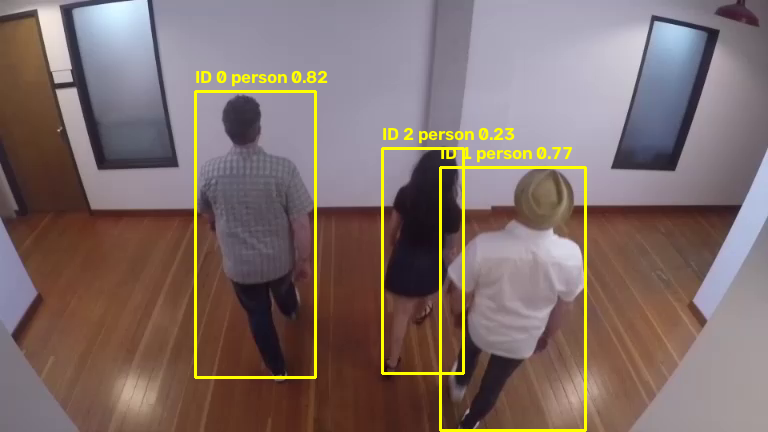

Detections: 3
0 person 0.82 [     81.344      67.966      131.56      279.94] raw_norm: 0.9999994 raw_shape: (448,)
1 person 0.77 [     183.43      124.07      243.91      318.65] raw_norm: 0.99999946 raw_shape: (448,)
2 person 0.23 [     159.41      109.63      192.97      276.73] raw_norm: 0.9999994 raw_shape: (448,)


In [ ]:
# Inspect a representative frame and annotate every proposal with a stable
# index. The selected index becomes the enrollment target in the next stage.
cap = cv2.VideoCapture(VIDEO_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)
if fps <= 0:
    fps = 30

cap.set(cv2.CAP_PROP_POS_FRAMES, int(fps * START_SECOND))

ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Could not read target frame")

detections = run_onnx_pyramid(frame)

preview = frame.copy()
h0, w0 = frame.shape[:2]
sx = w0 / IMG_SIZE
sy = h0 / IMG_SIZE

for i, det in enumerate(detections):
    x1, y1, x2, y2 = det["bbox_320"]

    x1o = int(x1 * sx)
    y1o = int(y1 * sy)
    x2o = int(x2 * sx)
    y2o = int(y2 * sy)

    cv2.rectangle(preview, (x1o, y1o), (x2o, y2o), (0, 255, 255), 2)

    label = f"ID {i} {det['class_name']} {det['score']:.2f}"

    cv2.putText(
        preview,
        label,
        (x1o, max(20, y1o - 8)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 255),
        2,
    )

cv2_imshow(preview)

print("Detections:", len(detections))

for i, det in enumerate(detections):
    print(
        i,
        det["class_name"],
        f"{det['score']:.2f}",
        det["bbox_320"],
        "raw_norm:",
        np.linalg.norm(det["raw_feature"]),
        "raw_shape:",
        det["raw_feature"].shape,
    )

In [ ]:
# Build a short supervised enrollment set around the selected detection.
# Spatial continuity identifies the positive sample; same-class alternatives
# provide hard negatives that teach the mini-network target specificity.
TRAIN_FRAMES = 30
TARGET_ID = 2  # Replace this value when the preview shows a different target ID.

def bbox_center_320(bbox):
    x1, y1, x2, y2 = bbox
    return np.array([(x1 + x2) / 2.0, (y1 + y2) / 2.0], dtype=np.float32)

def bbox_distance_320(b1, b2):
    return float(np.linalg.norm(bbox_center_320(b1) - bbox_center_320(b2)))

def bbox_area_320(b):
    x1, y1, x2, y2 = b
    return max(1.0, float((x2 - x1) * (y2 - y1)))

def area_ratio_ok(b1, b2, min_ratio=0.45, max_ratio=2.2):
    a1 = bbox_area_320(b1)
    a2 = bbox_area_320(b2)
    r = a1 / a2
    return min_ratio <= r <= max_ratio

cap = cv2.VideoCapture(VIDEO_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)
if fps <= 0:
    fps = 30

cap.set(cv2.CAP_PROP_POS_FRAMES, int(fps * START_SECOND))

ret, frame = cap.read()
if not ret:
    cap.release()
    raise RuntimeError("Could not read start frame")

select_detections = run_onnx_pyramid(frame)

if TARGET_ID < 0 or TARGET_ID >= len(select_detections):
    cap.release()
    raise RuntimeError(
        f"TARGET_ID invalid. Available: 0 to {len(select_detections)-1}"
    )

target_class_id = select_detections[TARGET_ID]["class_id"]
last_bbox = select_detections[TARGET_ID]["bbox_320"]

print(
    "Training target:",
    TARGET_ID,
    select_detections[TARGET_ID]["class_name"],
    select_detections[TARGET_ID]["score"],
    last_bbox,
)

X_raw = []
y_train = []

for t in range(TRAIN_FRAMES):
    ret, frame = cap.read()
    if not ret:
        break

    detections = run_onnx_pyramid(frame)
    valid = [d for d in detections if d["raw_feature"] is not None]

    if len(valid) == 0:
        continue

    candidates = []

    for i, d in enumerate(valid):
        if d["class_id"] != target_class_id:
            continue

        if not area_ratio_ok(d["bbox_320"], last_bbox):
            continue

        dist = bbox_distance_320(d["bbox_320"], last_bbox)
        candidates.append((i, dist))

    if len(candidates) == 0:
        print("No valid positive candidate at frame", t)
        continue

    pos_idx = min(candidates, key=lambda x: x[1])[0]
    positive = valid[pos_idx]
    last_bbox = positive["bbox_320"]

    for i, det in enumerate(valid):
        X_raw.append(det["raw_feature"])
        y_train.append(1.0 if i == pos_idx else 0.0)

cap.release()

X_raw = torch.tensor(np.stack(X_raw), dtype=torch.float32, device=DEVICE)
y_train = torch.tensor(y_train, dtype=torch.float32, device=DEVICE)

print("X_raw:", X_raw.shape)
print("Positive:", int(y_train.sum().item()))
print("Negative:", int((y_train == 0).sum().item()))

Training target: 2 person 0.23328348994255066 [     159.41      109.63      192.97      276.73]
No valid positive candidate at frame 8
No valid positive candidate at frame 14
No valid positive candidate at frame 15
X_raw: torch.Size([82, 448])
Positive: 27
Negative: 55


In [ ]:
# Jointly optimize the embedding projection and binary classifier. Class
# weighting compensates for an unequal number of positive and negative ROIs.
embedding_head = EmbeddingHead(input_dim=448, embedding_dim=128).to(DEVICE)
clf = TargetClassifier(embedding_dim=128).to(DEVICE)

params = list(embedding_head.parameters()) + list(clf.parameters())

optimizer = torch.optim.Adam(
    params,
    lr=1e-3,
    weight_decay=1e-4,
)

pos_count = y_train.sum()
neg_count = len(y_train) - pos_count
pos_weight = neg_count / torch.clamp(pos_count, min=1.0)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

embedding_head.train()
clf.train()

for step in range(400):
    emb = embedding_head(X_raw)
    logits = clf(emb)

    loss = loss_fn(logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        with torch.no_grad():
            probs = torch.sigmoid(logits)
            pred = (probs > 0.5).float()
            acc = (pred == y_train).float().mean().item()

        print(f"step={step} loss={loss.item():.4f} acc={acc:.3f}")

embedding_head.eval()
clf.eval()

step=0 loss=0.9296 acc=0.671
step=50 loss=0.4127 acc=0.963
step=100 loss=0.1513 acc=0.988
step=150 loss=0.0663 acc=0.988
step=200 loss=0.0238 acc=1.000
step=250 loss=0.0148 acc=1.000
step=300 loss=0.0058 acc=1.000
step=350 loss=0.0032 acc=1.000


TargetClassifier(
  (net): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [ ]:
# The commented block below is retained as a baseline implementation. The
# active implementation that follows adds single-target selection, spatial
# gating, and temporal hysteresis to suppress ambiguous frame-level matches.
# cap = cv2.VideoCapture(VIDEO_PATH)

# fps = cap.get(cv2.CAP_PROP_FPS)
# if fps <= 0:
#     fps = 30

# w0 = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
# h0 = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# sx = w0 / IMG_SIZE
# sy = h0 / IMG_SIZE

# fourcc = cv2.VideoWriter_fourcc(*"mp4v")
# out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (w0, h0))

# frame_idx = 0

# while True:
#     ret, frame = cap.read()

#     if not ret:
#         break

#     detections = run_onnx_pyramid(frame)

#     best_idx = None
#     best_score = -1.0

#     for i, det in enumerate(detections):
#         raw = det["raw_feature"]

#         if raw is None:
#             continue

#         x = torch.tensor(
#             raw[None, :],
#             dtype=torch.float32,
#             device=DEVICE,
#         )

#         with torch.no_grad():
#             emb = embedding_head(x)
#             logit = clf(emb)
#             target_score = float(torch.sigmoid(logit).item())

#         det["target_score"] = target_score

#         if target_score > best_score:
#             best_score = target_score
#             best_idx = i

#     for i, det in enumerate(detections):
#         x1, y1, x2, y2 = det["bbox_320"]

#         x1o = int(x1 * sx)
#         y1o = int(y1 * sy)
#         x2o = int(x2 * sx)
#         y2o = int(y2 * sy)

#         is_target = (
#             best_idx is not None
#             and i == best_idx
#             and best_score >= 0.50
#         )

#         color = (0, 255, 0) if is_target else (180, 180, 180)
#         thickness = 3 if is_target else 1

#         cv2.rectangle(frame, (x1o, y1o), (x2o, y2o), color, thickness)

#         label = f"{det['class_name']} {det['score']:.2f}"

#         if det["target_score"] is not None:
#             label += f" target={det['target_score']:.2f}"

#         if is_target:
#             label = "TARGET " + label

#             cx = (x1o + x2o) // 2
#             cy = (y1o + y2o) // 2

#             cv2.circle(frame, (cx, cy), 6, (0, 255, 0), -1)

#         cv2.putText(
#             frame,
#             label,
#             (x1o, max(20, y1o - 8)),
#             cv2.FONT_HERSHEY_SIMPLEX,
#             0.55,
#             color,
#             2,
#         )

#     cv2.putText(
#         frame,
#         f"Best target score: {best_score:.2f}",
#         (20, 40),
#         cv2.FONT_HERSHEY_SIMPLEX,
#         1.0,
#         (0, 255, 0) if best_score >= 0.50 else (0, 0, 255),
#         2,
#     )

#     out.write(frame)

#     frame_idx += 1

#     if frame_idx % 30 == 0:
#         print("Processed frames:", frame_idx)

#     if frame_idx >= MAX_FRAMES:
#         break

# cap.release()
# out.release()

# print("Saved:", OUTPUT_PATH)
# files.download(OUTPUT_PATH)

TARGET_ACCEPT_THRESHOLD = 0.40
TARGET_HOLD_FRAMES = 15

cap = cv2.VideoCapture(VIDEO_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)
if fps <= 0:
    fps = 30

w0 = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h0 = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

sx = w0 / IMG_SIZE
sy = h0 / IMG_SIZE

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (w0, h0))

frame_idx = 0

last_good_bbox = None
missing_count = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    detections = run_onnx_pyramid(frame)

    best_idx = None
    best_score = -1.0

    for i, det in enumerate(detections):
        raw = det["raw_feature"]

        if raw is None:
            continue

        x = torch.tensor(
            raw[None, :],
            dtype=torch.float32,
            device=DEVICE,
        )

        with torch.no_grad():
            emb = embedding_head(x)
            logit = clf(emb)
            target_score = float(torch.sigmoid(logit).item())

        det["target_score"] = target_score

        if target_score > best_score:
            best_score = target_score
            best_idx = i

    has_confident_target = (
        best_idx is not None
        and best_score >= TARGET_ACCEPT_THRESHOLD
    )

    if has_confident_target:
        last_good_bbox = detections[best_idx]["bbox_320"]
        missing_count = 0
    else:
        missing_count += 1

    for i, det in enumerate(detections):
        x1, y1, x2, y2 = det["bbox_320"]

        x1o = int(x1 * sx)
        y1o = int(y1 * sy)
        x2o = int(x2 * sx)
        y2o = int(y2 * sy)

        is_target = (
            best_idx is not None
            and i == best_idx
            and best_score >= TARGET_ACCEPT_THRESHOLD
        )

        color = (0, 255, 0) if is_target else (180, 180, 180)
        thickness = 3 if is_target else 1

        cv2.rectangle(
            frame,
            (x1o, y1o),
            (x2o, y2o),
            color,
            thickness,
        )

        label = f"{det['class_name']} {det['score']:.2f}"

        if det["target_score"] is not None:
            label += f" target={det['target_score']:.2f}"

        if is_target:
            label = "TARGET " + label

            cx = (x1o + x2o) // 2
            cy = (y1o + y2o) // 2

            cv2.circle(
                frame,
                (cx, cy),
                6,
                (0, 255, 0),
                -1,
            )

        cv2.putText(
            frame,
            label,
            (x1o, max(20, y1o - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            color,
            2,
        )

    if (
        not has_confident_target
        and last_good_bbox is not None
        and missing_count <= TARGET_HOLD_FRAMES
    ):
        x1, y1, x2, y2 = last_good_bbox

        x1o = int(x1 * sx)
        y1o = int(y1 * sy)
        x2o = int(x2 * sx)
        y2o = int(y2 * sy)

        cv2.rectangle(
            frame,
            (x1o, y1o),
            (x2o, y2o),
            (0, 200, 255),
            2,
        )

        cv2.putText(
            frame,
            f"HOLD target missing={missing_count}",
            (x1o, max(20, y1o - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 200, 255),
            2,
        )

    cv2.putText(
        frame,
        f"Best target score: {best_score:.2f}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (0, 255, 0) if best_score >= TARGET_ACCEPT_THRESHOLD else (0, 0, 255),
        2,
    )

    out.write(frame)

    frame_idx += 1

    if frame_idx % 30 == 0:
        print("Processed frames:", frame_idx)

    if frame_idx >= MAX_FRAMES:
        break

cap.release()
out.release()

print("Saved:", OUTPUT_PATH)

files.download(OUTPUT_PATH)

Processed frames: 30
Processed frames: 60
Processed frames: 90
Processed frames: 120
Processed frames: 150
Processed frames: 180
Processed frames: 210
Processed frames: 240
Processed frames: 270
Processed frames: 300
Processed frames: 330
Processed frames: 360
Processed frames: 390
Processed frames: 420
Processed frames: 450
Processed frames: 480
Processed frames: 510
Processed frames: 540
Processed frames: 570
Saved: user_selected_object_tracking.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
# Install the ONNX-to-TensorFlow conversion toolchain with compatible versions.
!pip install -q -U \
    onnx2tf \
    onnxruntime \
    onnx \
    onnx-graphsurgeon \
    sng4onnx \
    tf-keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.5/223.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 112.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9

In [8]:
# Convert the exported ONNX graph and select the unquantized float32 artifact.
import os
import glob
import shutil
import subprocess
import numpy as np
import tensorflow as tf

ONNX_PATH = "user_selected_object_yolo_p3_p4_p5.onnx"
OUTPUT_DIR = "tflite_export"
TFLITE_PATH = "user_selected_object_yolo_p3_p4_p5.tflite"

if not os.path.exists(ONNX_PATH):
    raise FileNotFoundError(
        f"{ONNX_PATH} not found. Сначала запустите ячейку 3 "
        "из target_detection.ipynb."
    )

shutil.rmtree(OUTPUT_DIR, ignore_errors=True)

subprocess.run(
    [
        "onnx2tf",
        "-i", ONNX_PATH,
        "-o", OUTPUT_DIR,

        # Фиксированный вход YOLO
        "-ois", "image:1,3,320,320",

        # По возможности сохранить имена и порядок выходов
        "-coion",

        "-v", "info",
    ],
    check=True,
)

# Locate the float32 TFLite artifact produced by the converter.
candidates = glob.glob(
    os.path.join(OUTPUT_DIR, "**", "*.tflite"),
    recursive=True,
)

float32_candidates = [
    path for path in candidates
    if "float32" in path.lower()
]

candidates = float32_candidates or candidates

if not candidates:
    raise RuntimeError(
        f"onnx2tf did not create a TFLite file in {OUTPUT_DIR}"
    )

# The unquantized float32 model is typically the largest generated artifact.
converted_path = max(candidates, key=os.path.getsize)

shutil.copyfile(converted_path, TFLITE_PATH)

print("Converter output:", converted_path)
print("Final model:", TFLITE_PATH)
print(
    "Size:",
    round(os.path.getsize(TFLITE_PATH) / 1024 / 1024, 2),
    "MB",
)

Converter output: tflite_export/user_selected_object_yolo_p3_p4_p5_float32.tflite
Final model: user_selected_object_yolo_p3_p4_p5.tflite
Size: 12.1 MB


In [9]:
# Verify the TFLite interface, tensor layouts, expected feature channels,
# and numerical stability using a complete synthetic inference pass.
interpreter = tf.lite.Interpreter(
    model_path=TFLITE_PATH,
    num_threads=4,
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("INPUTS:")
for item in input_details:
    print(
        "name:", item["name"],
        "shape:", item["shape"],
        "dtype:", item["dtype"],
    )

print("\nOUTPUTS:")
for item in output_details:
    print(
        "name:", item["name"],
        "shape:", item["shape"],
        "dtype:", item["dtype"],
    )

if len(input_details) != 1:
    raise RuntimeError(
        f"Ожидался один вход, получено: {len(input_details)}"
    )

if len(output_details) != 4:
    raise RuntimeError(
        f"Ожидалось четыре выхода, получено: {len(output_details)}"
    )

shapes = [
    list(map(int, item["shape"]))
    for item in output_details
]

# The YOLO output may use either [1, 84, N] or [1, N, 84] layout.
has_yolo = any(
    len(shape) == 3 and 84 in shape
    for shape in shapes
)

# Feature maps may use either NCHW or NHWC layout after conversion.
found_channels = {
    channels
    for shape in shapes
    if len(shape) == 4
    for channels in (64, 128, 256)
    if shape[1] == channels or shape[-1] == channels
}

if not has_yolo:
    raise RuntimeError(
        f"YOLO-выход [1,84,N] или [1,N,84] не найден: {shapes}"
    )

if found_channels != {64, 128, 256}:
    raise RuntimeError(
        "Не найдены все P3/P4/P5 feature maps. "
        f"Найденные каналы: {found_channels}; формы: {shapes}"
    )

# Execute a smoke-test inference to detect invalid values or interface errors.
input_info = input_details[0]

test_input = np.random.random(
    input_info["shape"]
).astype(np.float32)

interpreter.set_tensor(
    input_info["index"],
    test_input,
)

interpreter.invoke()

for item in output_details:
    output = interpreter.get_tensor(item["index"])

    print(
        item["name"],
        "shape:", output.shape,
        "min:", float(output.min()),
        "max:", float(output.max()),
    )

    if not np.isfinite(output).all():
        raise RuntimeError(
            f"Output {item['name']} contains NaN or Infinity"
        )

print("\nTFLite model validated successfully")

INPUTS:
name: image shape: [  1 320 320   3] dtype: <class 'numpy.float32'>

OUTPUTS:
name: yolo_raw shape: [   1   84 2100] dtype: <class 'numpy.float32'>
name: p3 shape: [ 1 64 40 40] dtype: <class 'numpy.float32'>
name: p4 shape: [  1 128  20  20] dtype: <class 'numpy.float32'>
name: p5 shape: [  1 256  10  10] dtype: <class 'numpy.float32'>
yolo_raw shape: (1, 84, 2100) min: 1.414743647752681e-12 max: 337.986328125
p3 shape: (1, 64, 40, 40) min: -0.27846455574035645 max: 3.1889841556549072
p4 shape: (1, 128, 20, 20) min: -0.27846455574035645 max: 2.4109785556793213
p5 shape: (1, 256, 10, 10) min: -0.27846452593803406 max: 3.7132794857025146

TFLite model validated successfully


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [10]:
# Download the validated model for integration with the Flutter application.
from google.colab import files

files.download("user_selected_object_yolo_p3_p4_p5.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>